- Importing necessary Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle as p

- Loading the Data

In [4]:
df = pd.read_csv("Dataset.csv")
print(df.sample(5))
# 0 for normal and 1 for fraudulent transaction
print("Summary of dataset\n",df.describe())

            Time        V1        V2        V3        V4        V5        V6  \
40107    40096.0  0.744615 -1.206351 -1.875486 -0.693986  1.808576  3.260431   
167125  118497.0 -0.969411  2.067611 -2.613569 -0.332106  1.481126 -1.470034   
224519  143838.0  1.984632 -0.251099 -0.474903  0.495908 -0.565859 -0.243839   
98181    66554.0 -0.860966  1.229546  2.189185  0.576448  0.465697  0.003350   
190917  129032.0  2.116870 -0.322073 -1.662635 -0.951771  0.337134 -0.427941   

              V7        V8        V9  ...       V21       V22       V23  \
40107   0.028584  0.634954  0.078408  ...  0.049911 -0.579335 -0.399425   
167125  0.864077  0.533273 -1.219145  ...  0.201348  0.539811 -0.206080   
224519 -0.885079  0.124540  1.322152  ... -0.031871  0.047331  0.329985   
98181   1.044707 -0.581557  0.280364  ... -0.254470  0.123062 -0.214789   
190917 -0.017744 -0.101378  0.613208  ... -0.288822 -0.820712  0.308172   

             V24       V25       V26       V27       V28  Amount  Cl

- Analyzing Class Distribution

In [5]:
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(round(outlierFraction,4))
print('Fraud Cases: {}'.format(len(df[df['Class'] == 1])))
print('Valid Transactions: {}'.format(len(df[df['Class'] == 0])))

0.0017
Fraud Cases: 492
Valid Transactions: 284315


-  Exploring Transaction Amounts of Valid Transactions

In [6]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

-  Exploring Transaction Amounts of Valid Transactions

In [7]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

- Plotting Correlation Matrix

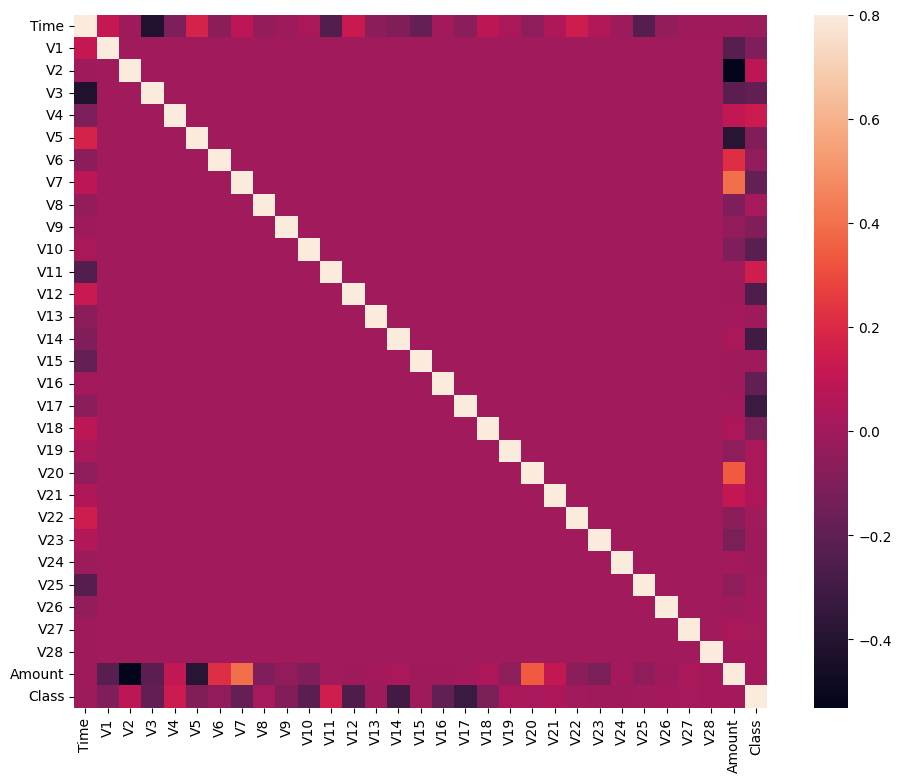

In [8]:
corrmat = df.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8,square = True)
plt.show()

- Preparing Data

In [9]:
X = df.drop(['Class'], axis = 1)
Y = df["Class"]
print(X.shape)
print(Y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42)

(284807, 30)
(284807,)


- Building and Training the Model

In [10]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

- Evaluating the model

Model Evaluation Metrics:
Accuracy: 100.00%
Precision: 97.00%
Recall: 79.00%
F1-Score: 87.00%


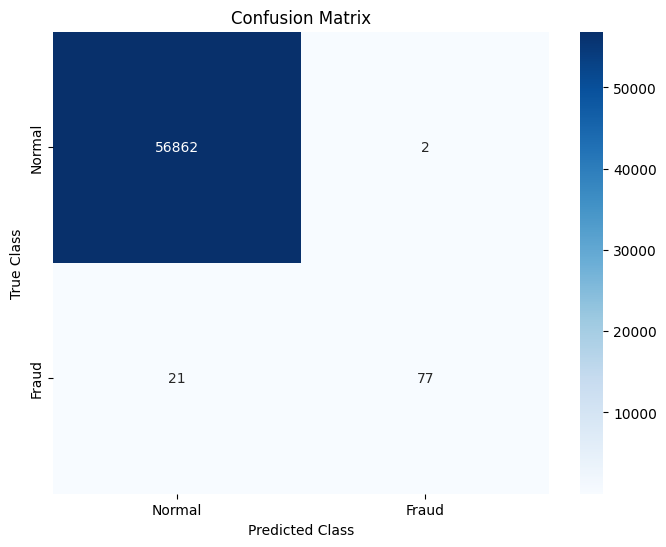

In [11]:
accuracy = round(accuracy_score(y_test, y_pred),2)*100
precision = round(precision_score(y_test, y_pred),2)*100
recall = round(recall_score(y_test, y_pred),2)*100
f1 = round(f1_score(y_test, y_pred),2)*100

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1-Score: {f1:.2f}%")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

- Feature Importance Graph

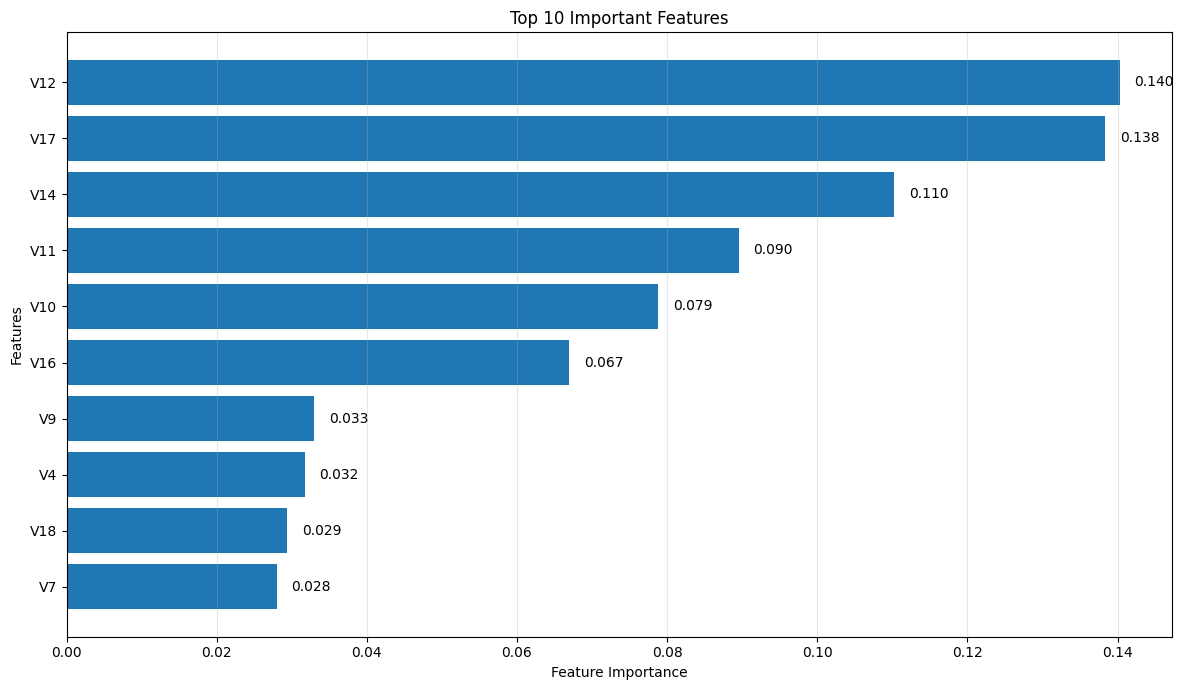

In [16]:
feature_names = X_train.columns
importances = rfc.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
top10 = importance_df.head(10).sort_values(by="Importance")
plt.figure(figsize=(12, 7))
bars = plt.barh(top10["Feature"], top10["Importance"])
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=10
    )
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

- Exporting the model

In [41]:
p.dump(rfc,open("model.pkl","wb"))